In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


COLOR_SUCCESS = "tab:orange"
COLOR_FAIL = "tab:blue"

def find_file(*filenames):
    for filename in filenames:
        for p in [Path(filename), Path.cwd()/filename, Path("/mnt/data")/filename]:
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find any of: {filenames}")

details_path = find_file("order_details.csv", "order_details(3).csv")
timestamps_path = find_file("order_timestamp.csv", "order_timestamp(3).csv")

details = pd.read_csv(details_path)
timestamps = pd.read_csv(timestamps_path)

print("order_details shape:", details.shape)
print("order_timestamp shape:", timestamps.shape)


order_details shape: (151803, 10)
order_timestamp shape: (151803, 4)


In [2]:
for col in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[col] = pd.to_datetime(timestamps[col], errors="coerce")

df = details.merge(
    timestamps[["order_id", "start_time_slot", "accept_time", "arrived_pickup_at"]],
    on="order_id",
    how="left",
    validate="one_to_one"
)


df["BATR_raw_min"] = (
    df["arrived_pickup_at"] - df["start_time_slot"]
).dt.total_seconds() / 60
df["BATR_min"] = df["BATR_raw_min"].clip(lower=0)

df["BATR15"] = np.where(
    df["BATR_min"].notna(),
    (df["BATR_min"] <= 15).astype(int),
    np.nan
)


df["AcceptanceTime_raw_min"] = (
    df["accept_time"] - df["start_time_slot"]
).dt.total_seconds() / 60
df["AcceptanceTime_min"] = df["AcceptanceTime_raw_min"].clip(lower=0)

df["AcceptanceTime10"] = np.where(
    df["AcceptanceTime_min"].notna(),
    (df["AcceptanceTime_min"] <= 10).astype(int),
    np.nan
)


df["ArrivalTime_raw_min"] = (
    df["arrived_pickup_at"] - df["accept_time"]
).dt.total_seconds() / 60
df["ArrivalTime_min"] = df["ArrivalTime_raw_min"].clip(lower=0)

df["ArrivalTime5"] = np.where(
    df["ArrivalTime_min"].notna(),
    (df["ArrivalTime_min"] <= 5).astype(int),
    np.nan
)

valid = df[
    df["BATR15"].notna()
    & df["AcceptanceTime_min"].notna()
    & df["ArrivalTime_min"].notna()
].copy()

valid["BATR15"] = valid["BATR15"].astype(int)
valid["AcceptanceTime10"] = valid["AcceptanceTime10"].astype(int)
valid["ArrivalTime5"] = valid["ArrivalTime5"].astype(int)


valid["Component_Sum_min"] = (
    valid["AcceptanceTime_min"] + valid["ArrivalTime_min"]
)
valid["Component_Residual_min"] = (
    valid["BATR_min"] - valid["Component_Sum_min"]
)

print(f"Valid orders for component analysis: {len(valid):,}")
print(f"BATR15=1: {(valid['BATR15']==1).sum():,} ({(valid['BATR15']==1).mean()*100:.2f}%)")
print(f"BATR15=0: {(valid['BATR15']==0).sum():,} ({(valid['BATR15']==0).mean()*100:.2f}%)")
print()
print(
    "Orders where corrected BATR differs from corrected Acceptance+Arrival by >0.01 min:",
    (valid["Component_Residual_min"].abs() > 0.01).sum()
)


Valid orders for component analysis: 151,579
BATR15=1: 117,402 (77.45%)
BATR15=0: 34,177 (22.55%)

Orders where corrected BATR differs from corrected Acceptance+Arrival by >0.01 min: 1


,Orders,Share (%)
BATR15,,
0,34177,22.55
1,117402,77.45


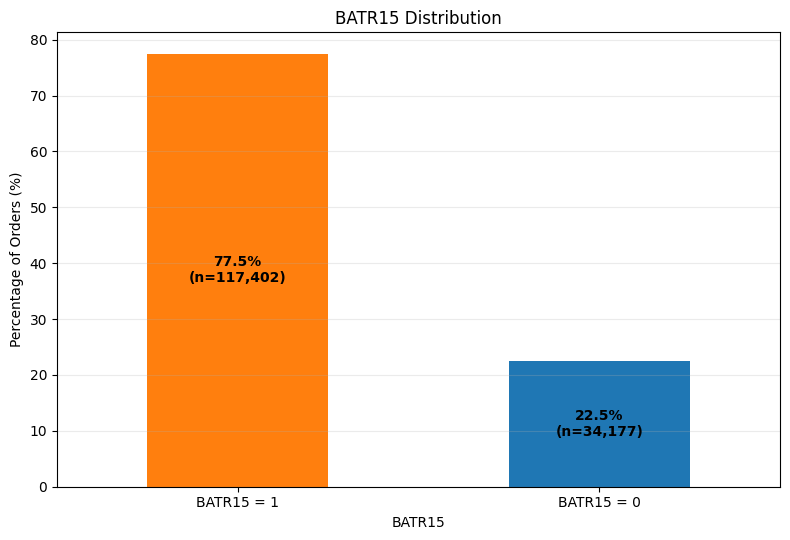

In [3]:
batr_group_counts = (
    valid["BATR15"]
    .value_counts()
    .sort_index()
    .rename("Orders")
    .to_frame()
)

batr_group_counts["Share (%)"] = (
    batr_group_counts["Orders"] / batr_group_counts["Orders"].sum() * 100
)

display(batr_group_counts)

ax = batr_group_counts.loc[[1, 0], "Share (%)"].plot(
    kind="bar",
    figsize=(8, 5.5),
    color=[COLOR_SUCCESS, COLOR_FAIL]
)

for i, status in enumerate([1, 0]):
    pct = batr_group_counts.loc[status, "Share (%)"]
    n = int(batr_group_counts.loc[status, "Orders"])
    ax.text(i, pct/2, f"{pct:.1f}%\n(n={n:,})",
            ha="center", va="center", fontweight="bold")

ax.set_title("BATR15 Distribution")
ax.set_xlabel("BATR15")
ax.set_ylabel("Percentage of Orders (%)")
ax.set_xticklabels(["BATR15 = 1", "BATR15 = 0"], rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [4]:
def q75(s): return s.quantile(0.75)
def q90(s): return s.quantile(0.90)
def q95(s): return s.quantile(0.95)

component_summary = (
    valid.groupby("BATR15")
         .agg(
             Orders=("order_id", "count"),
             Acceptance_Mean=("AcceptanceTime_min", "mean"),
             Acceptance_Median=("AcceptanceTime_min", "median"),
             Acceptance_P75=("AcceptanceTime_min", q75),
             Acceptance_P90=("AcceptanceTime_min", q90),
             Acceptance_P95=("AcceptanceTime_min", q95),
             Arrival_Mean=("ArrivalTime_min", "mean"),
             Arrival_Median=("ArrivalTime_min", "median"),
             Arrival_P75=("ArrivalTime_min", q75),
             Arrival_P90=("ArrivalTime_min", q90),
             Arrival_P95=("ArrivalTime_min", q95),
             BATR_Mean=("BATR_min", "mean"),
             BATR_Median=("BATR_min", "median"),
             BATR_P90=("BATR_min", q90)
         )
)

display(component_summary)

comparison = pd.DataFrame({
    "Metric": [
        "Acceptance Mean",
        "Acceptance Median",
        "Acceptance P90",
        "Arrival Mean",
        "Arrival Median",
        "Arrival P90"
    ],
    "BATR15=1": [
        component_summary.loc[1, "Acceptance_Mean"],
        component_summary.loc[1, "Acceptance_Median"],
        component_summary.loc[1, "Acceptance_P90"],
        component_summary.loc[1, "Arrival_Mean"],
        component_summary.loc[1, "Arrival_Median"],
        component_summary.loc[1, "Arrival_P90"]
    ],
    "BATR15=0": [
        component_summary.loc[0, "Acceptance_Mean"],
        component_summary.loc[0, "Acceptance_Median"],
        component_summary.loc[0, "Acceptance_P90"],
        component_summary.loc[0, "Arrival_Mean"],
        component_summary.loc[0, "Arrival_Median"],
        component_summary.loc[0, "Arrival_P90"]
    ]
})

comparison["Absolute Difference (min)"] = (
    comparison["BATR15=0"] - comparison["BATR15=1"]
)

display(comparison)


,Orders,Acceptance_Mean,Acceptance_Median,Acceptance_P75,Acceptance_P90,Acceptance_P95,Arrival_Mean,Arrival_Median,Arrival_P75,Arrival_P90,Arrival_P95,BATR_Mean,BATR_Median,BATR_P90
BATR15,,,,,,,,,,,,,,
0,34177,14.12,12.00,17.00,25.00,31.00,15.18,8.00,15.00,24.00,32.00,29.29,22.00,40.00
1,117402,1.65,0.00,2.00,7.00,10.00,3.20,3.00,5.00,8.00,9.00,4.84,4.00,13.00


,Metric,BATR15=1,BATR15=0,Absolute Difference (min)
0,Acceptance Mean,1.65,14.12,12.47
1,Acceptance Median,0.00,12.00,12.00
2,Acceptance P90,7.00,25.00,18.00
3,Arrival Mean,3.20,15.18,11.98
4,Arrival Median,3.00,8.00,5.00
5,Arrival P90,8.00,24.00,16.00


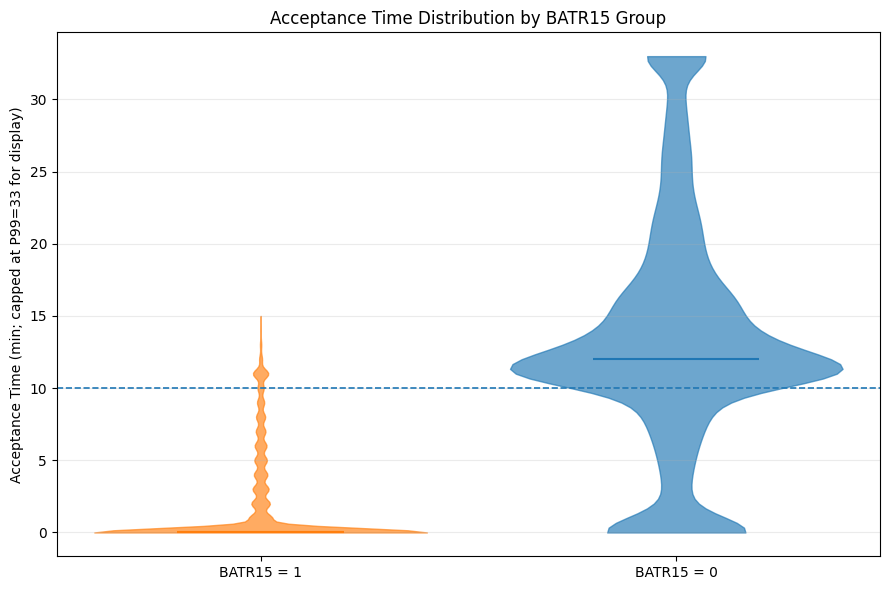

In [5]:
accept_p99 = valid["AcceptanceTime_min"].quantile(0.99)

accept_1 = valid.loc[
    valid["BATR15"] == 1, "AcceptanceTime_min"
].clip(upper=accept_p99).values

accept_0 = valid.loc[
    valid["BATR15"] == 0, "AcceptanceTime_min"
].clip(upper=accept_p99).values

fig, ax = plt.subplots(figsize=(9, 6))

parts1 = ax.violinplot(
    [accept_1],
    positions=[1],
    widths=0.8,
    showmedians=True,
    showextrema=False
)
for body in parts1["bodies"]:
    body.set_facecolor(COLOR_SUCCESS)
    body.set_edgecolor(COLOR_SUCCESS)
    body.set_alpha(0.65)
parts1["cmedians"].set_color(COLOR_SUCCESS)

parts0 = ax.violinplot(
    [accept_0],
    positions=[2],
    widths=0.8,
    showmedians=True,
    showextrema=False
)
for body in parts0["bodies"]:
    body.set_facecolor(COLOR_FAIL)
    body.set_edgecolor(COLOR_FAIL)
    body.set_alpha(0.65)
parts0["cmedians"].set_color(COLOR_FAIL)

ax.axhline(10, linestyle="--", linewidth=1.2)
ax.set_xticks([1, 2])
ax.set_xticklabels(["BATR15 = 1", "BATR15 = 0"])
ax.set_title("Acceptance Time Distribution by BATR15 Group")
ax.set_ylabel(f"Acceptance Time (min; capped at P99={accept_p99:.0f} for display)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


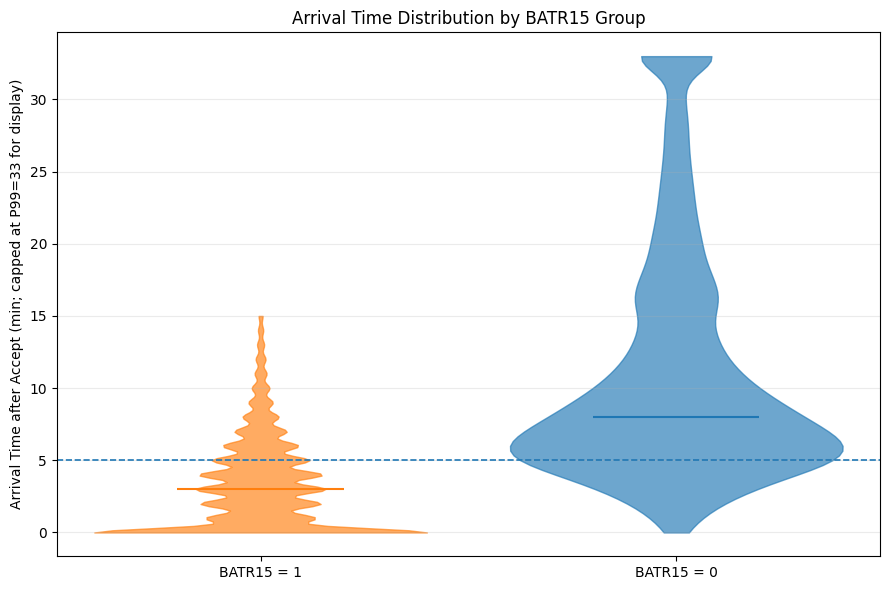

In [6]:
arrival_p99 = valid["ArrivalTime_min"].quantile(0.99)

arrival_1 = valid.loc[
    valid["BATR15"] == 1, "ArrivalTime_min"
].clip(upper=arrival_p99).values

arrival_0 = valid.loc[
    valid["BATR15"] == 0, "ArrivalTime_min"
].clip(upper=arrival_p99).values

fig, ax = plt.subplots(figsize=(9, 6))

parts1 = ax.violinplot(
    [arrival_1],
    positions=[1],
    widths=0.8,
    showmedians=True,
    showextrema=False
)
for body in parts1["bodies"]:
    body.set_facecolor(COLOR_SUCCESS)
    body.set_edgecolor(COLOR_SUCCESS)
    body.set_alpha(0.65)
parts1["cmedians"].set_color(COLOR_SUCCESS)

parts0 = ax.violinplot(
    [arrival_0],
    positions=[2],
    widths=0.8,
    showmedians=True,
    showextrema=False
)
for body in parts0["bodies"]:
    body.set_facecolor(COLOR_FAIL)
    body.set_edgecolor(COLOR_FAIL)
    body.set_alpha(0.65)
parts0["cmedians"].set_color(COLOR_FAIL)

ax.axhline(5, linestyle="--", linewidth=1.2)
ax.set_xticks([1, 2])
ax.set_xticklabels(["BATR15 = 1", "BATR15 = 0"])
ax.set_title("Arrival Time Distribution by BATR15 Group")
ax.set_ylabel(f"Arrival Time after Accept (min; capped at P99={arrival_p99:.0f} for display)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


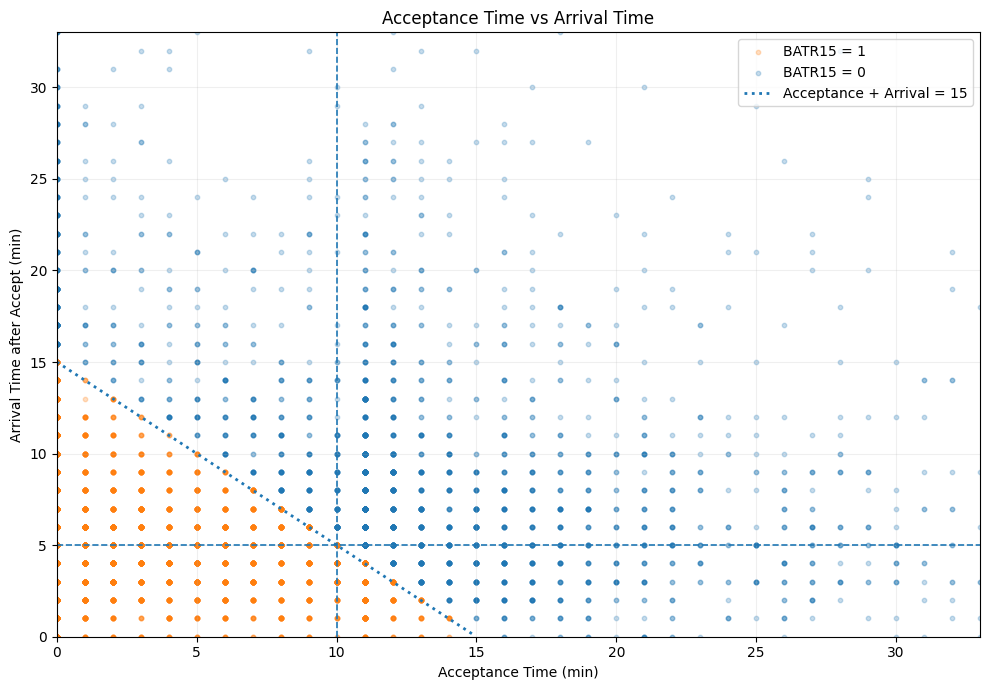

In [7]:
plot_sample = valid.sample(
    n=min(12000, len(valid)),
    random_state=42
).copy()

x_cap = valid["AcceptanceTime_min"].quantile(0.99)
y_cap = valid["ArrivalTime_min"].quantile(0.99)

plot_sample = plot_sample[
    (plot_sample["AcceptanceTime_min"] <= x_cap)
    & (plot_sample["ArrivalTime_min"] <= y_cap)
]

fig, ax = plt.subplots(figsize=(10, 7))

s1 = plot_sample[plot_sample["BATR15"] == 1]
s0 = plot_sample[plot_sample["BATR15"] == 0]

ax.scatter(
    s1["AcceptanceTime_min"],
    s1["ArrivalTime_min"],
    s=10,
    alpha=0.25,
    color=COLOR_SUCCESS,
    label="BATR15 = 1"
)

ax.scatter(
    s0["AcceptanceTime_min"],
    s0["ArrivalTime_min"],
    s=10,
    alpha=0.25,
    color=COLOR_FAIL,
    label="BATR15 = 0"
)

ax.axvline(10, linestyle="--", linewidth=1.2)
ax.axhline(5, linestyle="--", linewidth=1.2)

max_x = min(x_cap, 40)
x_line = np.linspace(0, max_x, 200)
y_line = 15 - x_line
mask = y_line >= 0

ax.plot(
    x_line[mask],
    y_line[mask],
    linestyle=":",
    linewidth=2,
    label="Acceptance + Arrival = 15"
)

ax.set_xlim(0, min(x_cap, 40))
ax.set_ylim(0, min(y_cap, 40))
ax.set_title("Acceptance Time vs Arrival Time")
ax.set_xlabel("Acceptance Time (min)")
ax.set_ylabel("Arrival Time after Accept (min)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [8]:
late = valid[valid["BATR15"] == 0].copy()

late["Acceptance_Fail"] = (late["AcceptanceTime10"] == 0).astype(int)
late["Arrival_Fail"] = (late["ArrivalTime5"] == 0).astype(int)

late["Failure_Source"] = np.select(
    [
        (late["AcceptanceTime10"] == 0) & (late["ArrivalTime5"] == 1),
        (late["AcceptanceTime10"] == 1) & (late["ArrivalTime5"] == 0),
        (late["AcceptanceTime10"] == 0) & (late["ArrivalTime5"] == 0),
    ],
    [
        "Acceptance only",
        "Arrival only",
        "Both"
    ],
    default="Neither"
)

source_order = ["Acceptance only", "Arrival only", "Both", "Neither"]

failure_counts = (
    late["Failure_Source"]
    .value_counts()
    .reindex(source_order, fill_value=0)
    .rename("Orders")
    .to_frame()
)

failure_counts["Share of BATR15=0 (%)"] = (
    failure_counts["Orders"] / failure_counts["Orders"].sum() * 100
)

display(failure_counts)


,Orders,Share of BATR15=0 (%)
Failure_Source,,
Acceptance only,8744,25.58
Arrival only,9455,27.66
Both,15978,46.75
Neither,0,0.00


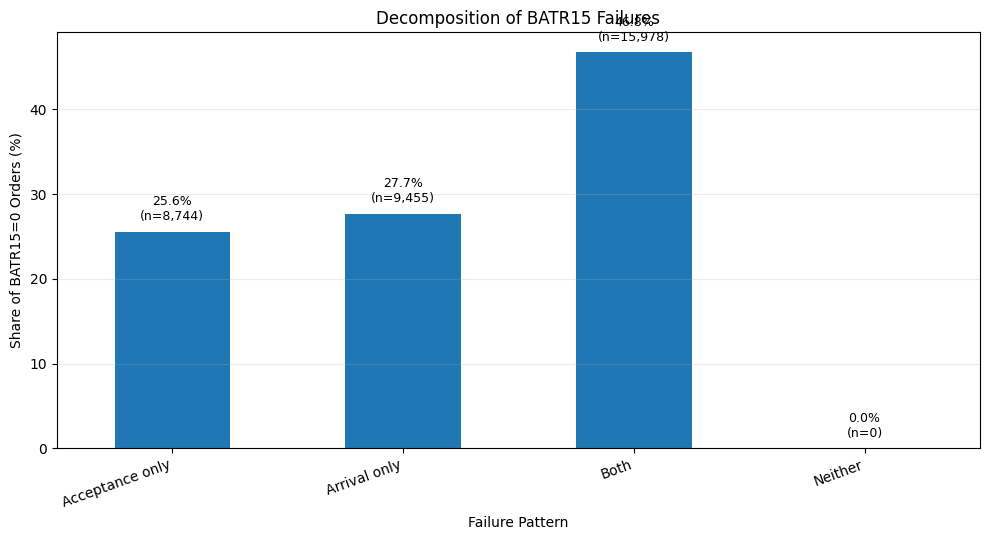

In [9]:
ax = failure_counts["Share of BATR15=0 (%)"].plot(
    kind="bar",
    figsize=(10, 5.5)
)

for i, category in enumerate(failure_counts.index):
    pct = failure_counts.loc[category, "Share of BATR15=0 (%)"]
    n = int(failure_counts.loc[category, "Orders"])
    ax.text(i, pct + 1, f"{pct:.1f}%\n(n={n:,})",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Decomposition of BATR15 Failures")
ax.set_xlabel("Failure Pattern")
ax.set_ylabel("Share of BATR15=0 Orders (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [10]:
accept_fail_share = late["Acceptance_Fail"].mean() * 100
arrival_fail_share = late["Arrival_Fail"].mean() * 100

nonexclusive = pd.DataFrame({
    "Component": ["Acceptance Time", "Arrival Time"],
    "Fail Share among BATR15=0 (%)": [
        accept_fail_share,
        arrival_fail_share
    ]
})

nonexclusive["Difference vs Other (pp)"] = [
    accept_fail_share - arrival_fail_share,
    arrival_fail_share - accept_fail_share
]

display(nonexclusive)


,Component,Fail Share among BATR15=0 (%),Difference vs Other (pp)
0,Acceptance Time,72.34,-2.08
1,Arrival Time,74.42,2.08


In [11]:
late["Acceptance_Excess_min"] = (
    late["AcceptanceTime_min"] - 10
).clip(lower=0)

late["Arrival_Excess_min"] = (
    late["ArrivalTime_min"] - 5
).clip(lower=0)

excess_summary = pd.DataFrame({
    "Component": ["Acceptance", "Arrival"],
    "Mean excess among BATR15=0 (min)": [
        late["Acceptance_Excess_min"].mean(),
        late["Arrival_Excess_min"].mean()
    ],
    "Median excess among BATR15=0 (min)": [
        late["Acceptance_Excess_min"].median(),
        late["Arrival_Excess_min"].median()
    ],
    "P90 excess among BATR15=0 (min)": [
        late["Acceptance_Excess_min"].quantile(0.90),
        late["Arrival_Excess_min"].quantile(0.90)
    ],
    "Total excess minutes": [
        late["Acceptance_Excess_min"].sum(),
        late["Arrival_Excess_min"].sum()
    ]
})

total_overage = excess_summary["Total excess minutes"].sum()
excess_summary["Share of component overage minutes (%)"] = (
    excess_summary["Total excess minutes"] / total_overage * 100
)

display(excess_summary)


,Component,Mean excess among BATR15=0 (min),Median excess among BATR15=0 (min),P90 excess among BATR15=0 (min),Total excess minutes,Share of component overage minutes (%)
0,Acceptance,5.72,2.00,15.00,"195,476.00",35.29
1,Arrival,10.49,3.00,19.00,"358,412.00",64.71


In [12]:
late["Dominant_Excess"] = np.select(
    [
        late["Acceptance_Excess_min"] > late["Arrival_Excess_min"],
        late["Arrival_Excess_min"] > late["Acceptance_Excess_min"]
    ],
    [
        "Acceptance excess larger",
        "Arrival excess larger"
    ],
    default="Equal"
)

dominant_excess = (
    late["Dominant_Excess"]
    .value_counts()
    .rename("Orders")
    .to_frame()
)

dominant_excess["Share of BATR15=0 (%)"] = (
    dominant_excess["Orders"] / dominant_excess["Orders"].sum() * 100
)

display(dominant_excess)


,Orders,Share of BATR15=0 (%)
Dominant_Excess,,
Arrival excess larger,17129,50.12
Acceptance excess larger,15288,44.73
Equal,1760,5.15


In [13]:
late["BATR_if_Acceptance_on_target"] = (
    np.minimum(late["AcceptanceTime_min"], 10)
    + late["ArrivalTime_min"]
)

late["BATR_if_Arrival_on_target"] = (
    late["AcceptanceTime_min"]
    + np.minimum(late["ArrivalTime_min"], 5)
)

acceptance_rescue = (
    late["BATR_if_Acceptance_on_target"] <= 15
).mean() * 100

arrival_rescue = (
    late["BATR_if_Arrival_on_target"] <= 15
).mean() * 100

repair_table = pd.DataFrame({
    "Single-stage arithmetic repair": [
        "Bring Acceptance to <=10",
        "Bring Arrival to <=5"
    ],
    "BATR15 failures mathematically recovered (%)": [
        acceptance_rescue,
        arrival_rescue
    ]
})

display(repair_table)


,Single-stage arithmetic repair,BATR15 failures mathematically recovered (%)
0,Bring Acceptance to <=10,25.58
1,Bring Arrival to <=5,27.66


In [14]:
city_nonexclusive = (
    late.groupby("order_city")
        .agg(
            Late_BATR_Orders=("order_id", "count"),
            Acceptance_Fail_Share=("Acceptance_Fail", "mean"),
            Arrival_Fail_Share=("Arrival_Fail", "mean")
        )
        .reset_index()
)

city_nonexclusive["Acceptance Fail (%)"] = (
    city_nonexclusive["Acceptance_Fail_Share"] * 100
)
city_nonexclusive["Arrival Fail (%)"] = (
    city_nonexclusive["Arrival_Fail_Share"] * 100
)

city_exclusive = (
    late.groupby(["order_city", "Failure_Source"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=source_order, fill_value=0)
)

city_exclusive_pct = (
    city_exclusive.div(city_exclusive.sum(axis=1), axis=0) * 100
).reset_index()

city_driver = city_nonexclusive.merge(
    city_exclusive_pct,
    on="order_city",
    how="left"
)

city_driver["Driver Gap (pp)"] = (
    city_driver["Acceptance Fail (%)"]
    - city_driver["Arrival Fail (%)"]
)

city_driver["Primary Pattern"] = np.where(
    city_driver["Driver Gap (pp)"] > 3,
    "More Acceptance-heavy",
    np.where(
        city_driver["Driver Gap (pp)"] < -3,
        "More Arrival-heavy",
        "Similar / Both important"
    )
)

display(
    city_driver[
        [
            "order_city",
            "Late_BATR_Orders",
            "Acceptance Fail (%)",
            "Arrival Fail (%)",
            "Acceptance only",
            "Arrival only",
            "Both",
            "Driver Gap (pp)",
            "Primary Pattern"
        ]
    ].sort_values("Driver Gap (pp)", ascending=False)
)


,order_city,Late_BATR_Orders,Acceptance Fail (%),Arrival Fail (%),Acceptance only,Arrival only,Both,Driver Gap (pp),Primary Pattern
2,U,10359,72.99,72.96,27.04,27.01,45.95,0.03,Similar / Both important
1,K,21753,73.39,75.32,24.68,26.61,48.71,-1.94,Similar / Both important
0,B,2065,57.97,72.15,27.85,42.03,30.12,-14.19,More Arrival-heavy


In [15]:
district_nonexclusive = (
    late.groupby(["order_city", "district"])
        .agg(
            Late_BATR_Orders=("order_id", "count"),
            Acceptance_Fail_Share=("Acceptance_Fail", "mean"),
            Arrival_Fail_Share=("Arrival_Fail", "mean")
        )
        .reset_index()
)

district_nonexclusive["Acceptance Fail (%)"] = (
    district_nonexclusive["Acceptance_Fail_Share"] * 100
)
district_nonexclusive["Arrival Fail (%)"] = (
    district_nonexclusive["Arrival_Fail_Share"] * 100
)

district_exclusive = (
    late.groupby(["order_city", "district", "Failure_Source"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=source_order, fill_value=0)
)

district_exclusive_pct = (
    district_exclusive.div(
        district_exclusive.sum(axis=1),
        axis=0
    ) * 100
).reset_index()

district_driver = district_nonexclusive.merge(
    district_exclusive_pct,
    on=["order_city", "district"],
    how="left"
)

district_driver["Driver Gap (pp)"] = (
    district_driver["Acceptance Fail (%)"]
    - district_driver["Arrival Fail (%)"]
)

district_driver["Primary Pattern"] = np.where(
    district_driver["Driver Gap (pp)"] > 5,
    "Acceptance-heavy",
    np.where(
        district_driver["Driver Gap (pp)"] < -5,
        "Arrival-heavy",
        "Mixed / similar"
    )
)

district_driver_table = district_driver[
    [
        "order_city",
        "district",
        "Late_BATR_Orders",
        "Acceptance Fail (%)",
        "Arrival Fail (%)",
        "Acceptance only",
        "Arrival only",
        "Both",
        "Driver Gap (pp)",
        "Primary Pattern"
    ]
].sort_values(
    ["order_city", "Driver Gap (pp)"],
    ascending=[True, False]
)

display(district_driver_table)


,order_city,district,Late_BATR_Orders,Acceptance Fail (%),Arrival Fail (%),Acceptance only,Arrival only,Both,Driver Gap (pp),Primary Pattern
5,B,3752,7,71.43,57.14,42.86,28.57,28.57,14.29,Acceptance-heavy
3,B,3732,202,69.80,66.34,33.66,30.20,36.14,3.47,Mixed / similar
1,B,3724,234,65.81,65.81,34.19,34.19,31.62,0.00,Mixed / similar
0,B,3720,670,64.18,64.63,35.37,35.82,28.81,-0.45,Mixed / similar
2,B,3728,278,67.99,71.22,28.78,32.01,39.21,-3.24,Mixed / similar
4,B,3740,674,41.25,84.12,15.88,58.75,25.37,-42.88,Arrival-heavy
17,K,1528,2392,84.36,70.28,29.72,15.64,54.64,14.09,Acceptance-heavy
12,K,1492,8,100.00,87.50,12.50,0.00,87.50,12.50,Acceptance-heavy
15,K,1512,3367,81.08,72.94,27.06,18.92,54.02,8.14,Acceptance-heavy
8,K,1476,932,80.90,73.61,26.39,19.10,54.51,7.30,Acceptance-heavy


In [16]:
stable_districts = district_driver_table[
    district_driver_table["Late_BATR_Orders"] >= 30
].copy()

print("MOST ACCEPTANCE-HEAVY DISTRICTS")
display(
    stable_districts.sort_values(
        "Driver Gap (pp)",
        ascending=False
    ).head(15)
)

print("\nMOST ARRIVAL-HEAVY DISTRICTS")
display(
    stable_districts.sort_values(
        "Driver Gap (pp)",
        ascending=True
    ).head(15)
)


MOST ACCEPTANCE-HEAVY DISTRICTS


,order_city,district,Late_BATR_Orders,Acceptance Fail (%),Arrival Fail (%),Acceptance only,Arrival only,Both,Driver Gap (pp),Primary Pattern
23,U,1400,1256,82.48,66.48,33.52,17.52,48.96,16.00,Acceptance-heavy
17,K,1528,2392,84.36,70.28,29.72,15.64,54.64,14.09,Acceptance-heavy
24,U,1404,853,76.91,65.18,34.82,23.09,42.09,11.72,Acceptance-heavy
15,K,1512,3367,81.08,72.94,27.06,18.92,54.02,8.14,Acceptance-heavy
8,K,1476,932,80.90,73.61,26.39,19.10,54.51,7.30,Acceptance-heavy
11,K,1488,43,88.37,81.40,18.60,11.63,69.77,6.98,Acceptance-heavy
10,K,1484,1750,78.57,71.83,28.17,21.43,50.40,6.74,Acceptance-heavy
9,K,1480,8018,79.76,73.63,26.37,20.24,53.39,6.12,Acceptance-heavy
13,K,1496,400,79.75,74.50,25.50,20.25,54.25,5.25,Acceptance-heavy
3,B,3732,202,69.80,66.34,33.66,30.20,36.14,3.47,Mixed / similar



MOST ARRIVAL-HEAVY DISTRICTS


,order_city,district,Late_BATR_Orders,Acceptance Fail (%),Arrival Fail (%),Acceptance only,Arrival only,Both,Driver Gap (pp),Primary Pattern
20,K,4732,371,20.22,94.34,5.66,79.78,14.56,-74.12,Arrival-heavy
19,K,4532,804,22.76,89.93,10.07,77.24,12.69,-67.16,Arrival-heavy
18,K,4176,1187,34.63,89.05,10.95,65.37,23.67,-54.42,Arrival-heavy
4,B,3740,674,41.25,84.12,15.88,58.75,25.37,-42.88,Arrival-heavy
6,K,1468,672,62.50,81.10,18.90,37.50,43.60,-18.60,Arrival-heavy
30,U,1428,1945,68.02,77.79,22.21,31.98,45.81,-9.77,Arrival-heavy
14,K,1508,1709,67.88,76.48,23.52,32.12,44.35,-8.60,Arrival-heavy
25,U,1408,620,68.55,76.94,23.06,31.45,45.48,-8.39,Arrival-heavy
27,U,1416,814,71.74,77.03,22.97,28.26,48.77,-5.28,Arrival-heavy
31,U,1432,2374,70.98,74.35,25.65,29.02,45.32,-3.37,Mixed / similar


In [17]:
acc_only_pct = failure_counts.loc["Acceptance only", "Share of BATR15=0 (%)"]
arr_only_pct = failure_counts.loc["Arrival only", "Share of BATR15=0 (%)"]
both_pct = failure_counts.loc["Both", "Share of BATR15=0 (%)"]

acc_fail_pct = accept_fail_share
arr_fail_pct = arrival_fail_share

acc_med_good = component_summary.loc[1, "Acceptance_Median"]
acc_med_bad = component_summary.loc[0, "Acceptance_Median"]

arr_med_good = component_summary.loc[1, "Arrival_Median"]
arr_med_bad = component_summary.loc[0, "Arrival_Median"]

print("KEY RESULTS")
print("-" * 70)
print(
    f"Median Acceptance Time: BATR15=1 -> {acc_med_good:.1f} min | "
    f"BATR15=0 -> {acc_med_bad:.1f} min"
)
print(
    f"Median Arrival Time:    BATR15=1 -> {arr_med_good:.1f} min | "
    f"BATR15=0 -> {arr_med_bad:.1f} min"
)
print()
print(f"Among BATR15 failures:")
print(f"  Acceptance only: {acc_only_pct:.1f}%")
print(f"  Arrival only:    {arr_only_pct:.1f}%")
print(f"  Both fail:       {both_pct:.1f}%")
print()
print(f"Acceptance threshold missed in {acc_fail_pct:.1f}% of late orders.")
print(f"Arrival threshold missed in    {arr_fail_pct:.1f}% of late orders.")
print()

if both_pct >= max(acc_only_pct, arr_only_pct):
    print(
        "MAIN DIAGNOSTIC CONCLUSION: The largest failure group is 'Both'. "
        "Therefore poor BATR15 is not primarily a single-stage problem; "
        "Acceptance and post-accept Arrival frequently deteriorate together."
    )
else:
    if acc_only_pct > arr_only_pct:
        print(
            "MAIN DIAGNOSTIC CONCLUSION: Acceptance-only failures are more common "
            "than Arrival-only failures, suggesting the acceptance stage is the "
            "stronger standalone association with poor BATR15."
        )
    else:
        print(
            "MAIN DIAGNOSTIC CONCLUSION: Arrival-only failures are more common "
            "than Acceptance-only failures, suggesting the post-accept Arrival "
            "stage is the stronger standalone association with poor BATR15."
        )

if abs(acc_fail_pct - arr_fail_pct) < 5:
    print(
        "The overall failure prevalence of the two components is also close, "
        "so it would be misleading to attribute the BATR15 problem entirely to "
        "only one component."
    )
elif acc_fail_pct > arr_fail_pct:
    print("Acceptance threshold failure is materially more prevalent among late BATR orders.")
else:
    print("Arrival threshold failure is materially more prevalent among late BATR orders.")


KEY RESULTS
----------------------------------------------------------------------
Median Acceptance Time: BATR15=1 -> 0.0 min | BATR15=0 -> 12.0 min
Median Arrival Time:    BATR15=1 -> 3.0 min | BATR15=0 -> 8.0 min

Among BATR15 failures:
  Acceptance only: 25.6%
  Arrival only:    27.7%
  Both fail:       46.8%

Acceptance threshold missed in 72.3% of late orders.
Arrival threshold missed in    74.4% of late orders.

MAIN DIAGNOSTIC CONCLUSION: The largest failure group is 'Both'. Therefore poor BATR15 is not primarily a single-stage problem; Acceptance and post-accept Arrival frequently deteriorate together.
The overall failure prevalence of the two components is also close, so it would be misleading to attribute the BATR15 problem entirely to only one component.
